In [1]:
import numpy as np
import healpy as hp
import cmocean as cmo
import skytools as st 
import matplotlib.pyplot as plt

import skykit as tl

In [2]:
map_hpx = hp.read_map('HFI_353GHz_IntDR3_NoCMB_NoPS_5arcmin_map-zeroadjust-step3.fits', field=0)

In [3]:
map_patches = tl.healpix2tiles(map_hpx, 2048, 256, 64, margin_method='geometric')


In [7]:
map_patches_topo = tl.healpix2tiles(map_hpx, 2048, 256, 64, margin_method='topological')

In [4]:
map_from_patches = tl.tiles2healpix(map_patches)

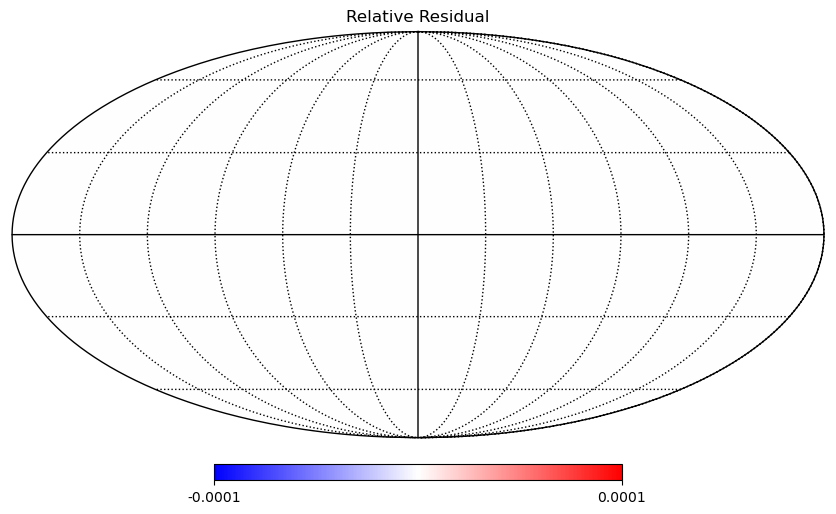

In [5]:
hp.mollview((map_hpx - map_from_patches)/map_hpx, cmap='bwr', min=-1e-4, max=1e-4, title="Relative Residual")
hp.graticule(dpar=30., dmer=30)

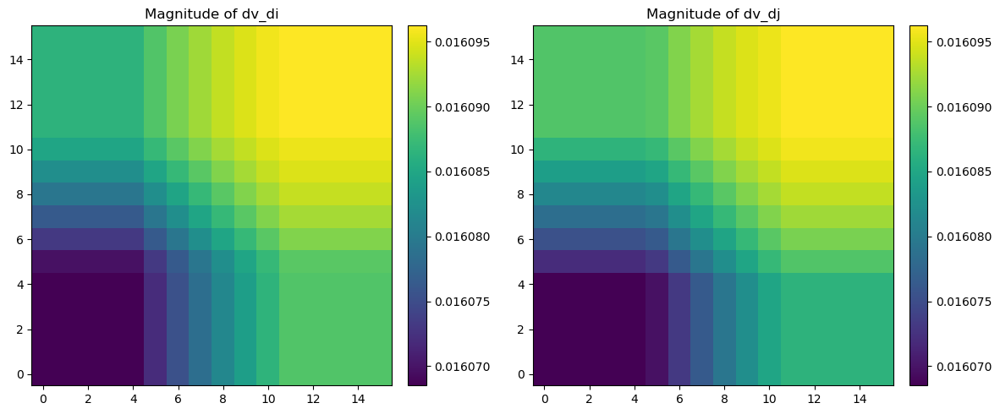

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skykit.healpix_tiling import HealpixTileProjector

# Re-initialize the projector with geometric method
proj = HealpixTileProjector(nside=64, tile_nside=8, margin=4, margin_method='geometric')

# Calculate the Euclidean magnitudes of the gradients across the tile
di_mag = np.linalg.norm(proj.debug_dv_di, axis=-1)
dj_mag = np.linalg.norm(proj.debug_dv_dj, axis=-1)

# Plot the maps
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im1 = axs[0].imshow(di_mag, cmap='viridis', origin='lower')
axs[0].set_title('Magnitude of dv_di')
plt.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)

im2 = axs[1].imshow(dj_mag, cmap='viridis', origin='lower')
axs[1].set_title('Magnitude of dv_dj')
plt.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [4]:
lon = 280.
lat = 90.
f, x, y = map_patches.tile_containing(lon, lat)

Text(0.5, 1.0, 'Tile indicating Interior vs Margin (interp)')

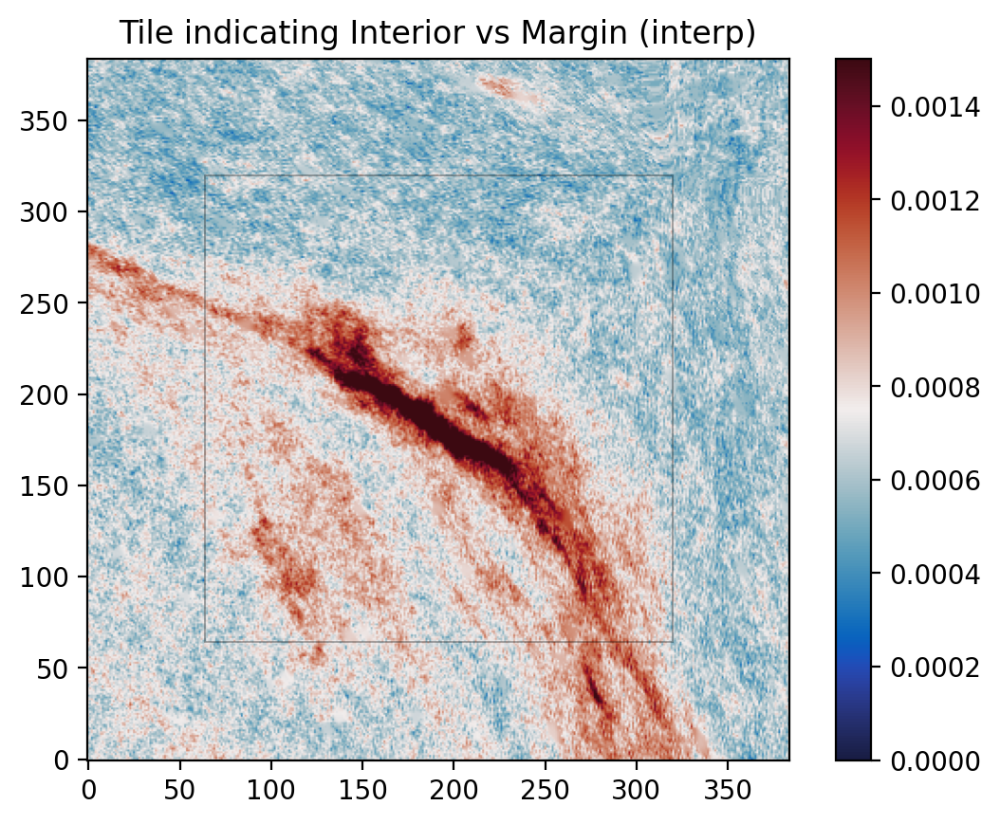

In [5]:
import matplotlib.patches as patches

fig, ax = plt.subplots(dpi=200)
im = ax.imshow(map_patches.get_tile(f, x, y).T, cmap=cmo.cm.balance, origin='lower', vmin=0, vmax=1.5e-3)
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)
ax.set_title("Tile indicating Interior vs Margin (interp)")

Text(0.5, 1.0, 'Tile indicating Interior vs Margin (topo)')

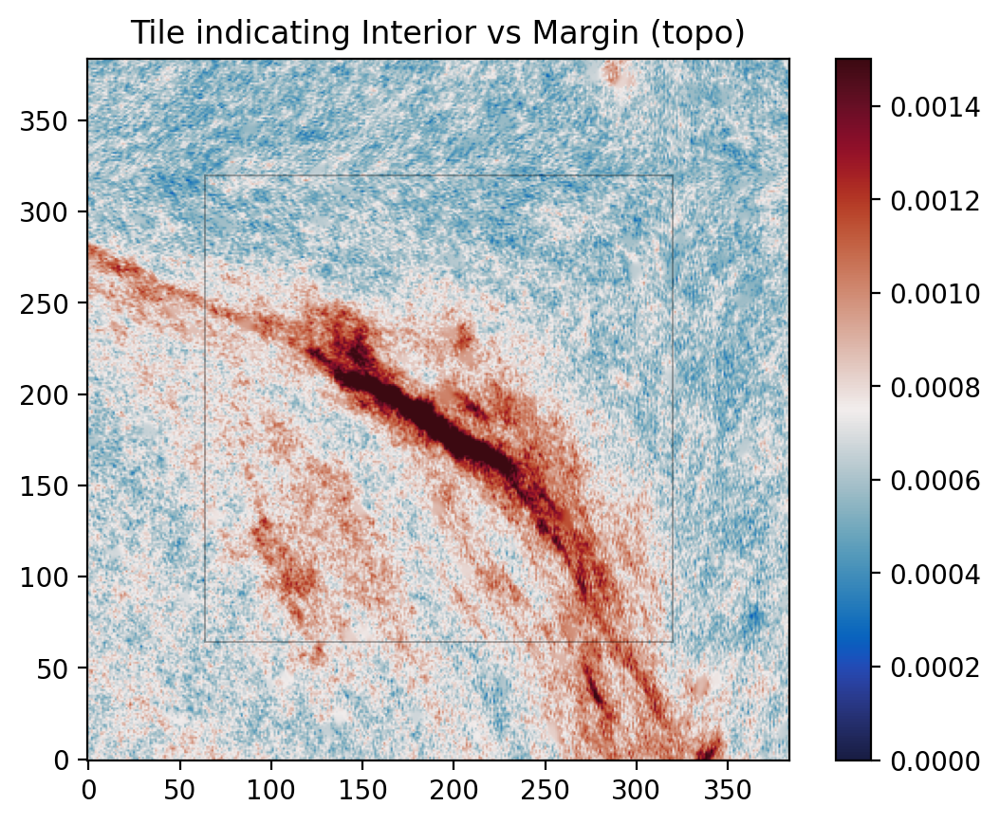

In [9]:
import matplotlib.patches as patches

fig, ax = plt.subplots(dpi=200)
im = ax.imshow(map_patches_topo.get_tile(f, x, y).T, cmap=cmo.cm.balance, origin='lower', vmin=0, vmax=1.5e-3)
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)
ax.set_title("Tile indicating Interior vs Margin (topo)")

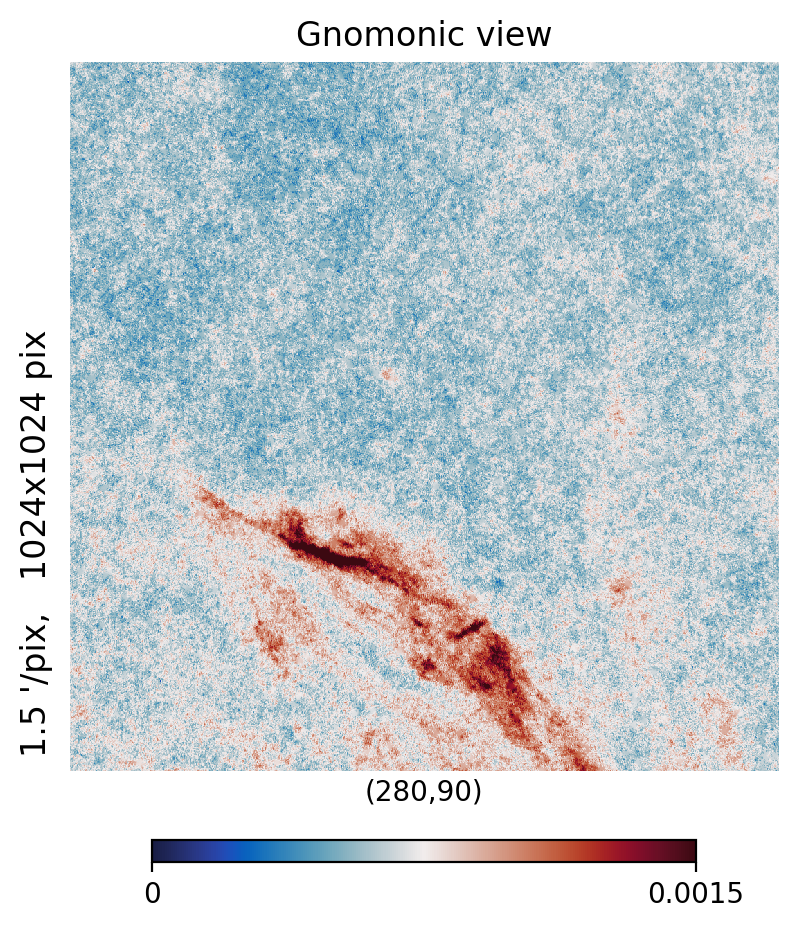

In [15]:
fig = plt.figure(dpi=200)
hp.gnomview(map_hpx, fig=fig.number, rot=(280,90,0), reso=1.5, xsize=1024, cmap=cmo.cm.balance, min=0, max=1.5e-3)

In [6]:
lon = 80.
lat = -90.
f, x, y = map_patches.tile_containing(lon, lat)

In [8]:
f, x, y

(8, 0, 0)

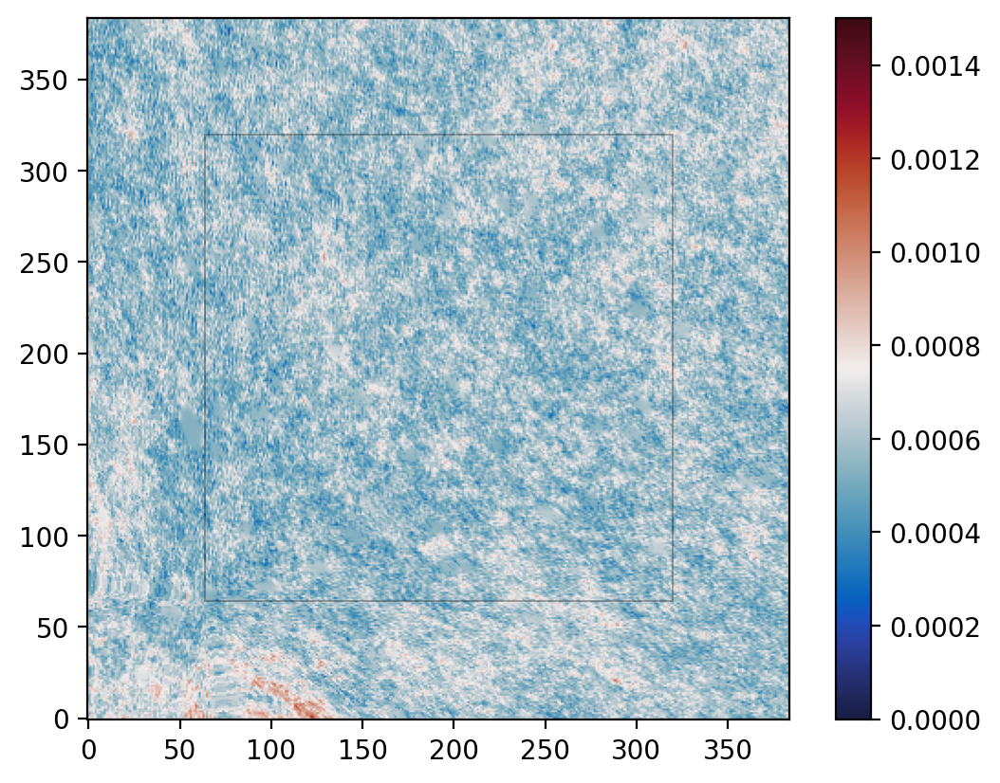

In [7]:
fig, ax = plt.subplots(dpi=200)
im =ax.imshow(map_patches.get_tile(f, x, y).T, cmap=cmo.cm.balance, origin='lower', vmin=0, vmax=1.5e-3)
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)

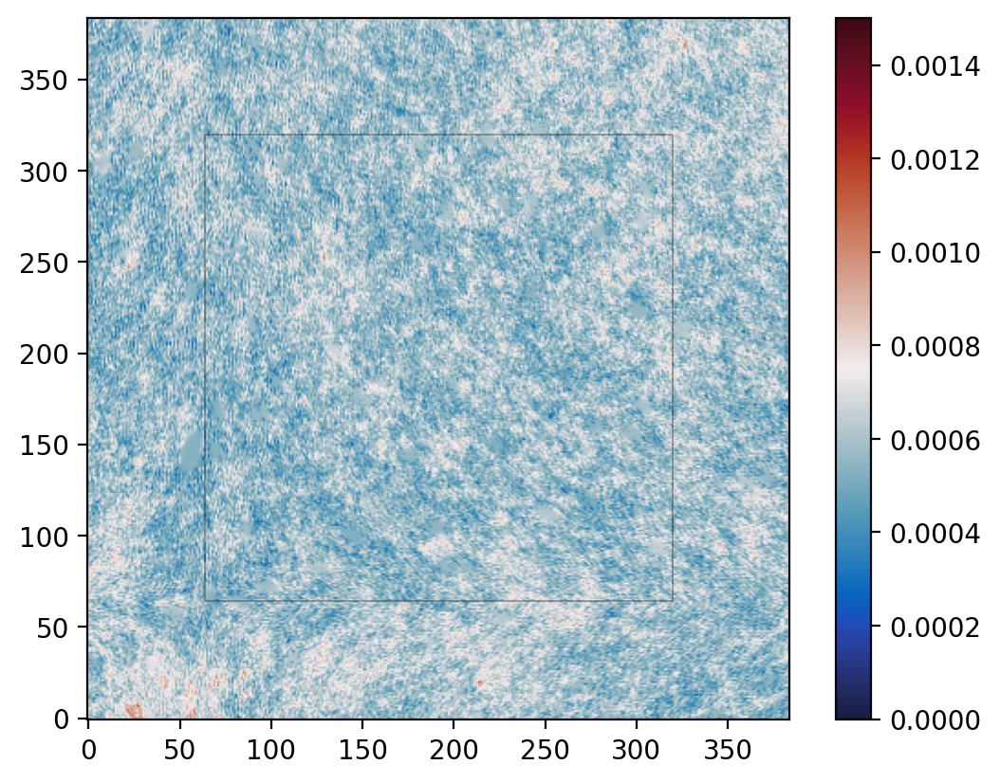

In [9]:
fig, ax = plt.subplots(dpi=200)
im =ax.imshow(map_patches_topo.get_tile(f, x, y).T, cmap=cmo.cm.balance, origin='lower', vmin=0, vmax=1.5e-3)
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)

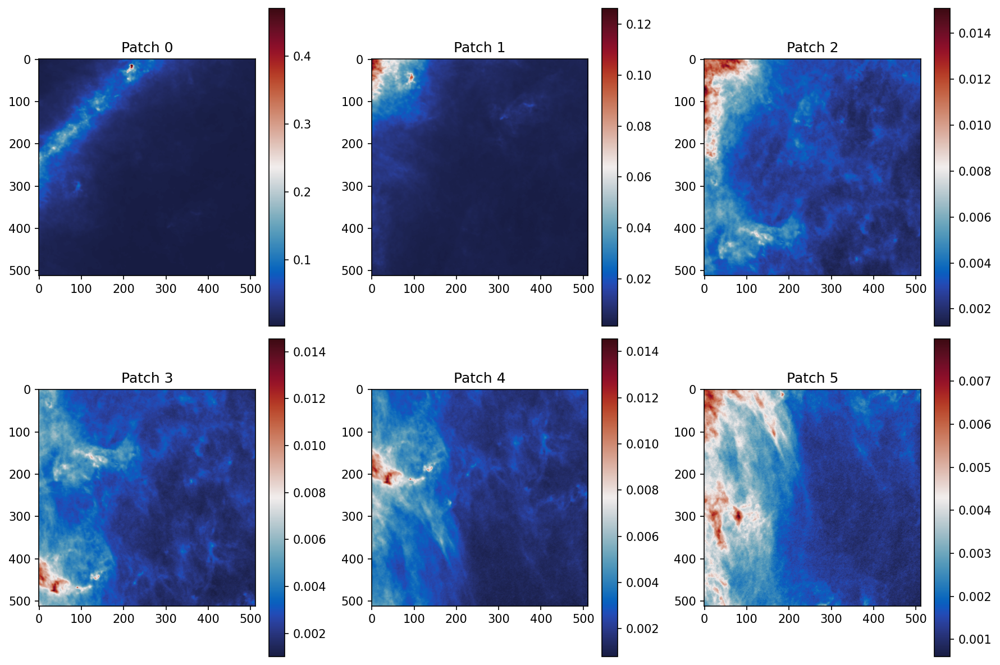

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(map_patches.data[i, :, :], cmap=cmo.cm.balance)
    ax.set_title(f'Patch {i}')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

/var/folders/yy/4xf19n1n7_31nlkz7lv1wh980000gn/T/ipykernel_69497/2563908303.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


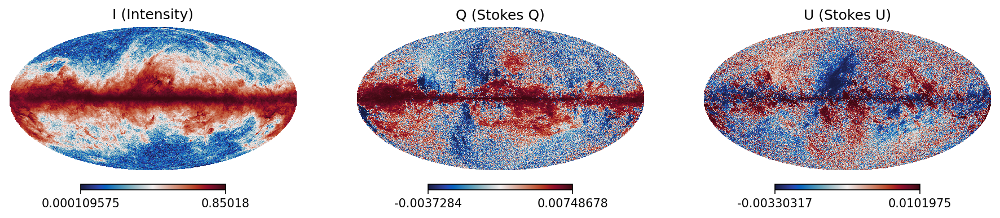

In [3]:
hpx_iqu_map = hp.read_map('../data/pr3/HFI_SkyMap_353-psb_2048_R3.01_full-evenring.fits', field=[0, 1, 2])
hpx_iqu_map[hpx_iqu_map == hp.UNSEEN] = 0.0
temp = hp.read_map('../data/pr3/HFI_SkyMap_353-psb_2048_R3.01_full-evenring.fits', field=[0, 1, 2])
temp[temp == hp.UNSEEN] = 0.0
hpx_iqu_map += temp

del temp

hpx_iqu_map /= 2.
hpx_iqu_map = hp.smoothing(hpx_iqu_map, fwhm=np.radians(7.5/60.), lmax=4000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
titles = ['I (Intensity)', 'Q (Stokes Q)', 'U (Stokes U)']
for i, (title, ax) in enumerate(zip(titles, axes)):
    plt.sca(ax)
    hp.mollview(hpx_iqu_map[i], title=title, cmap=cmo.cm.balance, hold=True,norm='hist')

plt.tight_layout()
plt.show()

In [4]:
qu_patches = tl.healpix2tiles(hpx_iqu_map[1:3], 2048, 256, 128, pol=True)
# qu_patches_rebin = tl.healpix2tiles(hpx_iqu_map[1:3], 2048, 256, 128, pol=True, rebin_margins=True)

In [6]:
lon = 280.
lat = 90.
f, x, y = qu_patches.tile_containing(lon, lat)

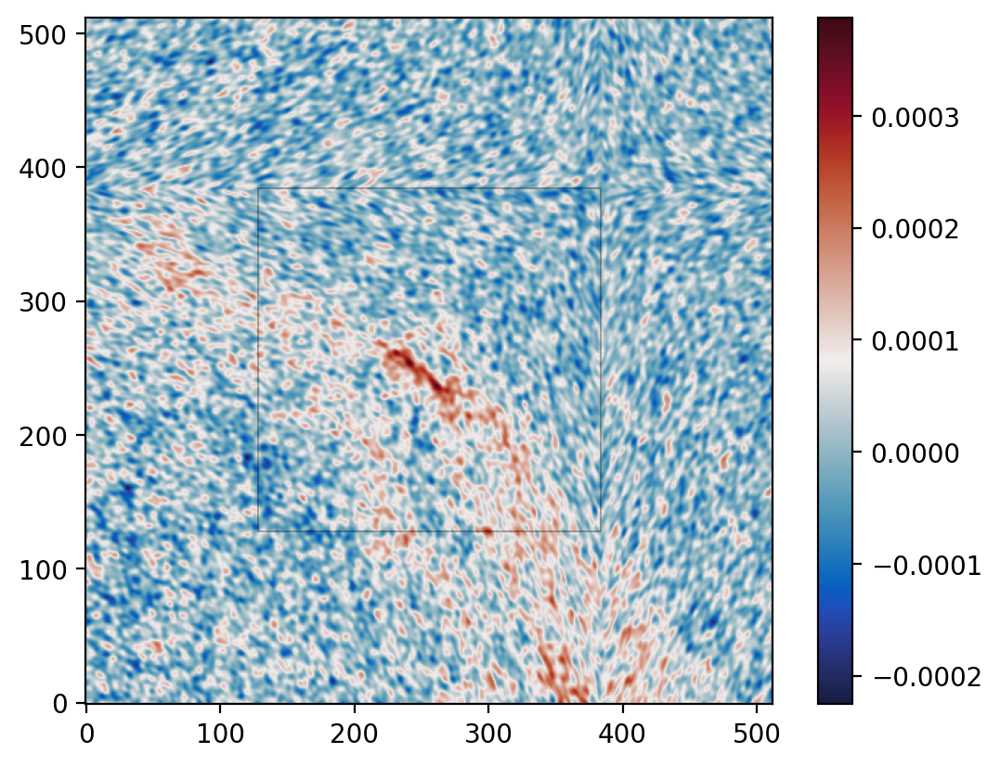

In [15]:
import matplotlib.patches as patches

fig, ax = plt.subplots(dpi=200)
im = ax.imshow(qu_patches.get_tile(f, x, y)[0].T, cmap=cmo.cm.balance, origin='lower')
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)

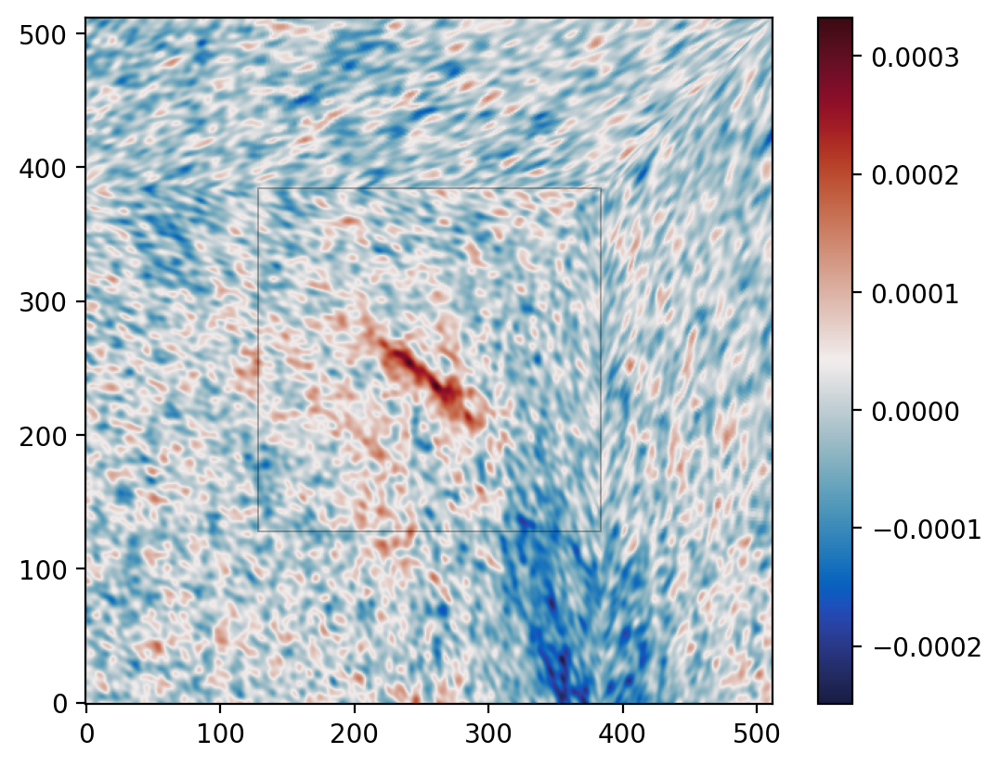

In [23]:
fig, ax = plt.subplots(dpi=200)
im = ax.imshow(qu_patches_rebin.get_tile(f, x, y)[0].T, cmap=cmo.cm.balance, origin='lower')
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)

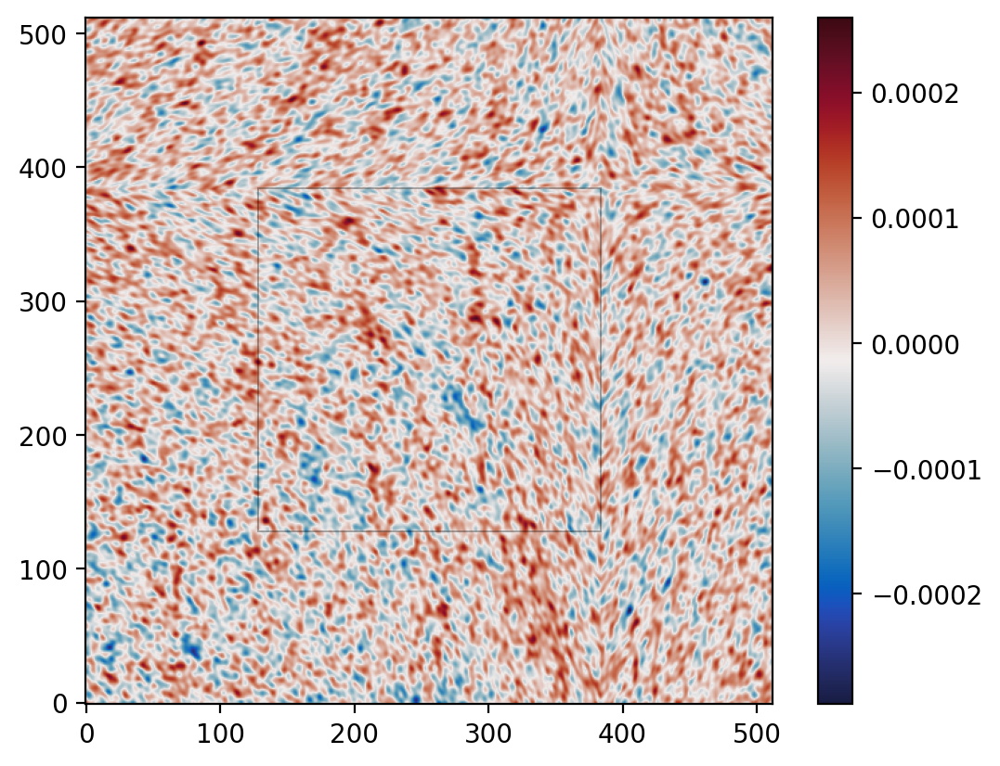

In [16]:
import matplotlib.patches as patches

fig, ax = plt.subplots(dpi=200)
im = ax.imshow(qu_patches.get_tile(f, x, y)[1].T, cmap=cmo.cm.balance, origin='lower')
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = qu_patches.margin
tile_nside = qu_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)

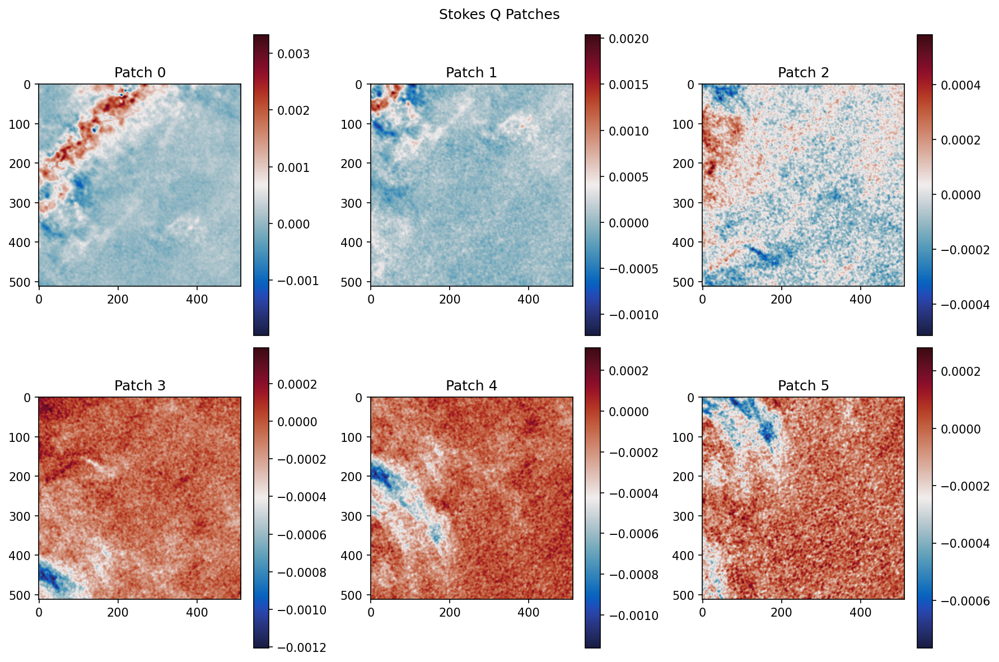

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(qu_patches.data[i, 0, :, :], cmap=cmo.cm.balance)
    ax.set_title(f'Patch {i}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Stokes Q Patches')
plt.tight_layout()
plt.show()

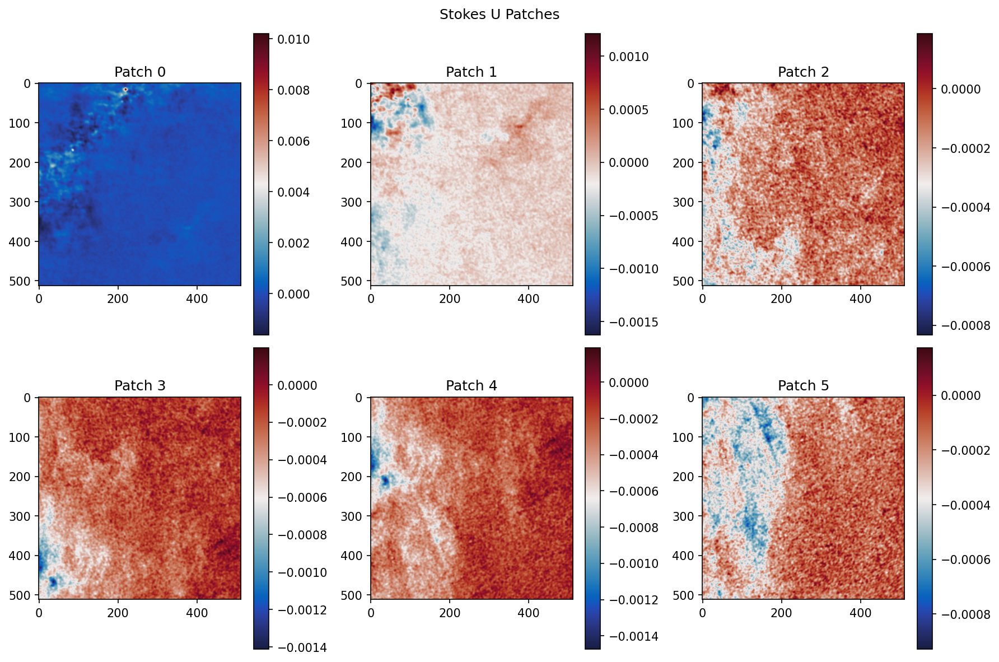

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=150)

for i, ax in enumerate(axes.flat):
    im = ax.imshow(qu_patches.data[i, 1, :, :], cmap=cmo.cm.balance)
    ax.set_title(f'Patch {i}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Stokes U Patches')
plt.tight_layout()
plt.show()

In [22]:
qu_map_from_patches = tl.tiles2healpix(qu_patches)

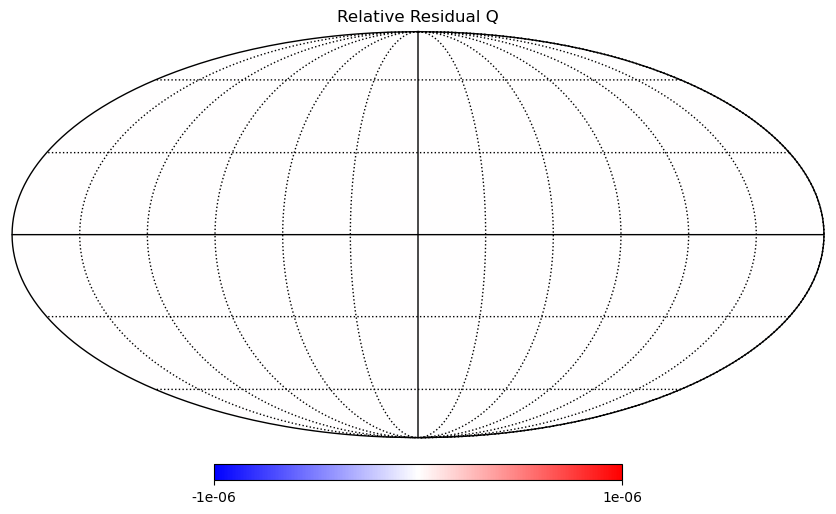

In [23]:
hp.mollview((hpx_iqu_map[1] - qu_map_from_patches[0])/hpx_iqu_map[1], cmap='bwr', min=-1e-6, max=1e-6, title="Relative Residual Q")
hp.graticule(dpar=30., dmer=30)

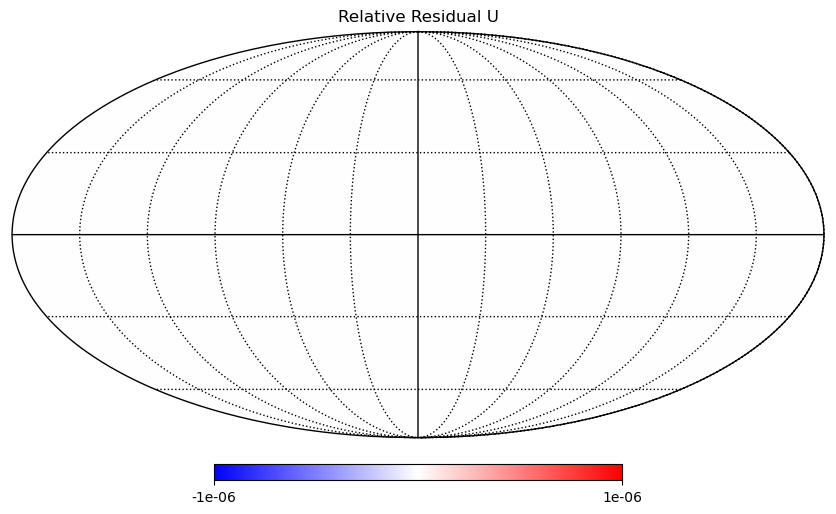

In [20]:
hp.mollview((hpx_iqu_map[2] - qu_map_from_patches[1])/hpx_iqu_map[2], cmap='bwr', min=-1e-6, max=1e-6, title="Relative Residual U")
hp.graticule(dpar=30., dmer=30)